# Baseline Probability of Default Model

This notebook builds a baseline credit risk model using logistic regression.

The objective is to predict whether a loan applicant may face repayment difficulty.

The target variable is `TARGET`.

- 0 = Applicant did not face repayment difficulty
- 1 = Applicant faced repayment difficulty

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
app_train = pd.read_csv("../data/raw/application_train.csv")

app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
target = "TARGET"

X = app_train.drop(columns=[target])
y = app_train[target]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (307511, 121)
Target data shape: (307511,)


In [4]:
y.value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

The target variable is imbalanced. Most applicants did not face repayment difficulty, while a smaller proportion did. This is common in credit risk modelling.

In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 105
Number of categorical features: 16


C:\Users\gsard\AppData\Local\Temp\ipykernel_14900\4015931719.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (246008, 121)
Testing data shape: (61503, 121)


In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

The preprocessing pipeline handles numerical and categorical variables separately.

Numerical variables are filled using median imputation and scaled.

Categorical variables are filled using the most frequent category and converted into numerical format using one-hot encoding.

In [8]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="saga"
        ))
    ]
)

In [9]:
model.fit(X_train, y_train)

c:\Users\gsard\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](121,)","['SK_ID_CURR','NAME_CONTRACT_TYPE','CODE_GENDER',..., 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,121
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [10]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

y_pred[:10], y_pred_proba[:10]

(array([0, 0, 1, 1, 1, 1, 0, 0, 1, 0]),
 array([0.34492913, 0.33641105, 0.76247852, 0.56477106, 0.57071174,
        0.62988531, 0.11247181, 0.07918351, 0.83355409, 0.44503951]))

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 68.99%


In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)

confusion_df = pd.DataFrame(
    conf_matrix,
    columns=["Predicted Non-Default", "Predicted Default"],
    index=["Actual Non-Default", "Actual Default"]
)

confusion_df

,Predicted Non-Default,Predicted Default
Actual Non-Default,39058,17480
Actual Default,1591,3374


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [14]:
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7483


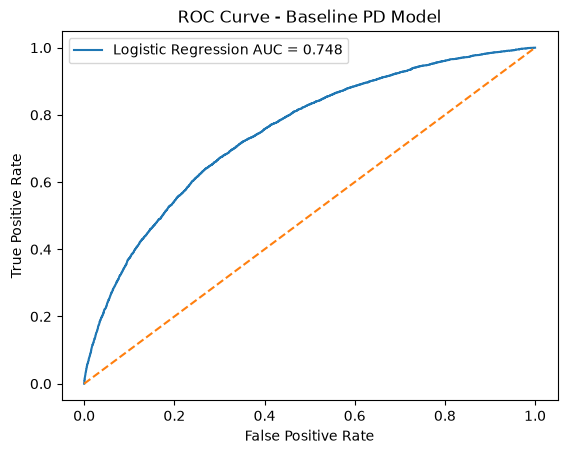

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline PD Model")
plt.legend()
plt.show()

In [16]:
results = X_test.copy()

results["Actual_Default"] = y_test
results["Predicted_Default"] = y_pred
results["Probability_of_Default"] = y_pred_proba

results[["Actual_Default", "Predicted_Default", "Probability_of_Default"]].head()

,Actual_Default,Predicted_Default,Probability_of_Default
256571,0,0,0.344929
191493,0,0,0.336411
103497,0,1,0.762479
130646,0,1,0.564771
211898,0,1,0.570712


In [17]:
def assign_risk_band(pd_value):
    if pd_value < 0.05:
        return "Low Risk"
    elif pd_value < 0.15:
        return "Medium Risk"
    elif pd_value < 0.30:
        return "High Risk"
    else:
        return "Very High Risk"

results["Risk_Band"] = results["Probability_of_Default"].apply(assign_risk_band)

results[["Actual_Default", "Probability_of_Default", "Risk_Band"]].head()


,Actual_Default,Probability_of_Default,Risk_Band
256571,0,0.344929,Very High Risk
191493,0,0.336411,Very High Risk
103497,0,0.762479,Very High Risk
130646,0,0.564771,Very High Risk
211898,0,0.570712,Very High Risk


In [18]:
risk_band_summary = results.groupby("Risk_Band").agg(
    Applicant_Count=("Actual_Default", "count"),
    Actual_Default_Rate=("Actual_Default", "mean"),
    Average_PD=("Probability_of_Default", "mean")
).sort_values("Average_PD")

risk_band_summary

,Applicant_Count,Actual_Default_Rate,Average_PD
Risk_Band,,,
Low Risk,100,0.000000,0.035890
Medium Risk,3931,0.013737,0.115422
High Risk,15414,0.024783,0.230562
Very High Risk,42058,0.107685,0.522521


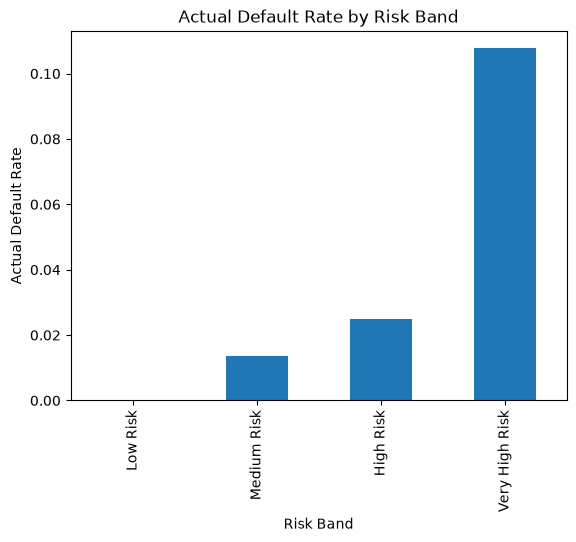

In [19]:
risk_band_summary["Actual_Default_Rate"].plot(kind="bar")

plt.title("Actual Default Rate by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Actual Default Rate")
plt.show()

In [20]:
results.to_csv("../data/processed/baseline_pd_predictions.csv", index=False)

## Baseline Model Interpretation

A baseline logistic regression model was built to estimate the Probability of Default for Home Credit loan applicants.

The model produces both class predictions and probability estimates.

The probability output is more useful in credit risk modelling because it allows applicants to be ranked by risk.

Applicants were classified into Low Risk, Medium Risk, High Risk, and Very High Risk bands based on predicted Probability of Default.

This baseline model provides a starting point for future improvement through feature engineering, model validation, and comparison with more advanced algorithms.